<a href="https://colab.research.google.com/github/denismedina08/Aulas-Mestre-Laurindo/blob/main/Laboratorio_Aula_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

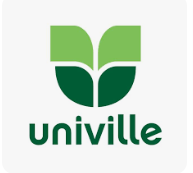

UNIVERSIDADE UNIVILLE

CURSO DE GRADUÇÃO

DISCIPLINA: FUNDAMENTO DA INTELIGÊNCIA ARTIFICIAL

PROF: LAURINDO DUMBA

# 1. Iterações repetidas - Loops e condicionais

In [ ]:
print('Bem-vindo ao ChatBot da Univille AI ! (Digite x se você desejar sair!)\n')
pergunta = input('Diga o seu nome e faça sua primeira pegunta: ')

while True:
  print(f'Bot: resposta do bot aqui')
  pergunta = input('Usuário: ')
  if pergunta.lower() == 'x':
    break

print(f'Muito obrigado por utilizar o Univille AI')

# 2. Armazenando interações - Listas, dicionários e funções

In [ ]:
print('Bem-vindo ao ChatBot da Univille AI ! (Digite x se você quiser sair!)\n')
mensagens = []
while True:
  pergunta = input('Usuário: ')
  if pergunta.lower() == 'x':
    break

  mensagens.append({'role': 'user', 'content': pergunta})
  resposta = 'Resposta do bot'
  mensagens.append({'role': 'assistant', 'content': resposta})
  print(f'Bot: {resposta}')

print('\nMuito obrigado por utilizar o Univille AI! O histórico completo da conversa foi:')
print(mensagens)

- Acessar o site da Groq e criar uma conta
- https://x.ai/grok
- Acessar o ambiente para gerar uma API Key
- https://console.groq.com/keys


# 3. Instalação da bibliotecas

In [ ]:
!pip install langchain==0.3.0
!pip install langchain-groq==0.2.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of langchain-core to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of langchain-core to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.8/311.8 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 5.8 MB/s eta 0:00:00


KeyboardInterrupt: 

# 4. Integrando o BOT com Groq

Uma "chain" (ou cadeia) refere-se a uma sequência de operações ou etapas que são encadeadas para processar informações e gerar resultados de forma estruturada. Cada etapa na chain pode envolver diferentes componentes, como prompts, modelos de linguagem, ferramentas de processamento de dados ou chamadas a APIs, permitindo que construamos fluxos de trabalho complexos e personalizados.

In [ ]:
import os # Interação de arquivos
from langchain_groq import ChatGroq

# Atenção: Está é a chave (api_key) do professor e ela será descontínuada após a aula.
# Cada aluno deve considerar em criar uma conta e uma chave. Na aula vou demonstrar quais passo seguir para criar a conta e a chave.

api_key = ''
os.environ['GROQ_API_KEY'] = api_key

chat = ChatGroq(model='llama-3.3-70b-versatile')

# 5. Criar um contexto

In [ ]:
from langchain.prompts import ChatPromptTemplate

template = ChatPromptTemplate.from_messages(
    [('user', 'Traduza {expressao} para a lingua {lingua}')]
)

# 6. Pedir para criar uma orientação passo à passo

In [ ]:
chain = template | chat

In [ ]:
resposta = chain.invoke({'expressao': 'Beleza?', 'lingua': 'inglesa'})

AuthenticationError: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'invalid_api_key'}}

In [ ]:
from langchain.prompts import ChatPromptTemplate

template = ChatPromptTemplate.from_messages(
    [('system', 'Você é um assistente que sempre responde com dicas de receitas de culinarias'),
     ('user', 'Traduza {expressao} para a lingua {lingua}')]
)
chain = template | chat
resposta = chain.invoke({'expressao': 'Café da amnhã?', 'lingua': 'Chinês'})
print(resposta.content)

In [ ]:
import os
from langchain_groq import ChatGroq
from langchain.prompts import ChatPromptTemplate


# Atenção Turma: Está é a chave (api_key) do professor e ela será descontínuada após a aula.
# Cada aluno deve considerar em criar uma conta e uma chave. Na aula vou demonstrar quais passo seguir para criar a conta e a chave.

api_key = ''
os.environ['GROQ_API_KEY'] = api_key

chat = ChatGroq(model='llama-3.3-70b-versatile')

def resposta_bot(mensagens):
  mensagens_modelo = [('system', 'Você é um treinador de futebol da Univille AI ')]
  mensagens_modelo += mensagens
  template = ChatPromptTemplate.from_messages(mensagens_modelo)
  chain = template | chat
  return chain.invoke({}).content

print('Bem-vindo ao Univille AI')

mensagens = []
while True:
  pergunta = input('Usuario: ')
  if pergunta.lower() == 'x':
    break
  mensagens.append(('user', pergunta))
  resposta = resposta_bot(mensagens)
  mensagens.append(('assistant', resposta))
  print(f'Bot: {resposta}')

print('Muito obrigado por usar o Univille AI')
print(mensagens)

Bem-vindo ao Univille AI
Usuario: oi
Bot: Olá! É um prazer conversar com você! Como treinador de futebol da Univille AI, estou aqui para ajudar e discutir sobre o esporte que amamos.

Você é um torcedor do time da Univille AI ou apenas um entusiasta do futebol em geral? Qual é o seu time favorito?

Vamos conversar sobre futebol! O que você gostaria de saber ou discutir? Estratégias de jogo, jogadores, táticas, ou algo mais? Estou aqui para ajudar!
Usuario: x
Muito obrigado por usar o Univille AI
[('user', 'oi'), ('assistant', 'Olá! É um prazer conversar com você! Como treinador de futebol da Univille AI, estou aqui para ajudar e discutir sobre o esporte que amamos.\n\nVocê é um torcedor do time da Univille AI ou apenas um entusiasta do futebol em geral? Qual é o seu time favorito?\n\nVamos conversar sobre futebol! O que você gostaria de saber ou discutir? Estratégias de jogo, jogadores, táticas, ou algo mais? Estou aqui para ajudar!')]


# CHAT BOT FINAL - UNIBOT

* `Turma, criamos o nosso primeiro  ChatBot conversacional, ainda temos muito do que explorar e existem inumeras possibilidade para personalizar o ChatBot de acordo com as nossas necessidades.
Ousem experimentar outras possibilidade em contextos diferentes e testam o máximo que for possivel para entendermos o nível de aprendizado que podemos abstrair deste primeiro laboratório.`

# [EXERCÍCIOS - DIY  "Do It Yourself" (Faça Você Mesmo)]


* `Criei e personalize novos contextos para interagir com o Bot`

In [ ]:
import os
from langchain_groq import ChatGroq
from langchain.prompts import ChatPromptTemplate

# Defina sua chave de API corretamente
os.environ["GROQ_API_KEY"] = ""

chat = ChatGroq(model='llama-3.3-70b-versatile')

def resposta_bot(mensagens):
    mensagens_modelo = [
        ("system",
         "Você é um analista de suporte de TI especializado na área de negócios da empresa. "
         "Fornece suporte para os usuários de áreas como financeiro, comercial e operacional com problemas de sistemas, acessos, e aplicações corporativas relacionadas á área. "
         "Responda de forma clara, objetiva e com linguagem simples, sem termos muito técnicos para melhor entendimento. "
         "Sempre que possível, sugira passos práticos para resolver o problema.")
    ]

    mensagens_modelo += mensagens

    template = ChatPromptTemplate.from_messages(mensagens_modelo)
    chain = template | chat

    return chain.invoke({}).content


print("Bem-vindo ao Suporte de TI - Área de Negócios")

mensagens = []

while True:
    pergunta = input("Usuário: ")

    if pergunta.lower() in ['x', 'sair']:
        break

    mensagens.append(("user", pergunta))
    resposta = resposta_bot(mensagens)
    mensagens.append(("assistant", resposta))

    print(f"Bot: {resposta}")

print("✅ Atendimento finalizado. Obrigado!")

Bem-vindo ao Suporte de TI - Área de Negócios


KeyboardInterrupt: Interrupted by user